In [1]:
from pathlib import Path
import sys

In [2]:
def find_project_root(start=None):
    if start is None:
        start = Path.cwd().resolve()
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    return start


PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import settings as S

from src.io.pitch_io import load_preprocessed_pitch, load_flat_regions, load_peaks
from src.features.structural_embedding import (
    label_samples_sil_cp_sta,
    map_peaks_to_global_rows,
    restrict_peaks_to_slice,
    build_segments_for_one_svara,
    assign_segment_cents,
)

In [4]:
recording_id = "srs_v1_svd_sav"

tonic_hz = S.SARASUDA_TONICS[recording_id]
tau_init_sil = 0.30

df_pitch = load_preprocessed_pitch(
    recording_id=recording_id,
    root_dir=PROJECT_ROOT / "data/interim",
    tonic_hz=tonic_hz,
    convert_to_cents=True,
)

df_flat = load_flat_regions(
    recording_id=recording_id,
    root_dir=PROJECT_ROOT / "data/interim",
)

df_peaks = load_peaks(
    recording_id=recording_id,
    root_dir=PROJECT_ROOT / "data/interim",
)

df_pitch = (
    df_pitch.join(
        df_flat.select(["time_rel_sec", "flat_region"]),
        on="time_rel_sec",
        how="left",
    )
    .with_columns(pl.col("flat_region").fill_null(False))
    .with_row_index("row_idx")
)

peak_row_map = map_peaks_to_global_rows(df_pitch, df_peaks)

print(df_pitch.shape, df_peaks.shape)

(44810, 12) (3205, 10)


In [5]:
def debug_one_annotated_svara_structural_segmentation(
    df_pitch: pl.DataFrame,
    df_svaras: pl.DataFrame,
    peak_row_map: dict[int, float],
    segment_id: int,
    tau_init_sil: float = 0.30,
):
    """
    Debug one annotated svara (one row from df_svaras).

    Parameters
    ----------
    df_pitch : pl.DataFrame
        Full pitch dataframe for one recording. Must already include:
        - row_idx
        - flat_region
        - f0_savgol_p3_w13
        - f0_savgol_p3_w13_cents

    df_svaras : pl.DataFrame
        Annotation dataframe with:
        - start_time_sec
        - end_time_sec
        - svara_label

    peak_row_map : dict[int, float]
        Mapping {global_row_idx: value_savgol_cents}

    segment_id : int
        Row index inside df_svaras (i.e. annotated svara index)

    tau_init_sil : float
        Threshold for initial silence handling.

    Returns
    -------
    df_svara : pl.DataFrame
        Sliced svara dataframe
    df_debug : pl.DataFrame
        Per-sample debug dataframe
    df_segments : pl.DataFrame
        One row per structural segment
    segments : list[dict]
        Raw Python segment structures
    local_peak_map : dict[int, float]
        Local peak positions inside this svara
    """

    if segment_id < 0 or segment_id >= df_svaras.height:
        raise IndexError(f"segment_id={segment_id} out of range for df_svaras.height={df_svaras.height}")

    ann = df_svaras.row(segment_id, named=True)

    t_start = float(ann["start_time_sec"])
    t_end = float(ann["end_time_sec"])
    if t_end < t_start:
        t_start, t_end = t_end, t_start

    # Slice pitch by annotation interval
    t_all = df_pitch["time_rel_sec"].to_numpy()
    mask = (t_all >= t_start) & (t_all <= t_end)
    df_svara = df_pitch.filter(pl.Series(mask))

    if df_svara.is_empty():
        raise ValueError(f"No pitch rows found for annotated segment_id={segment_id}")

    # Label samples with SIL > CP > STA precedence
    df_svara = label_samples_sil_cp_sta(df_svara)

    # Restrict peaks to this slice and convert to local row positions
    local_peak_map = restrict_peaks_to_slice(df_svara, peak_row_map)

    # Build structural segments
    segments = build_segments_for_one_svara(
        df_svara=df_svara,
        local_peak_map=local_peak_map,
    )

    # Assign representative pitch to each segment
    segments = assign_segment_cents(
        segments=segments,
        df_svara=df_svara,
        df_full=df_pitch,
        tau_init_sil=tau_init_sil,
        local_peak_map=local_peak_map,
    )

    # Build readable segment table
    times = df_svara["time_rel_sec"].to_numpy()
    cents = df_svara["f0_savgol_p3_w13_cents"].to_numpy()

    rows = []
    for k, seg in enumerate(segments):
        s = seg["start"]
        e = seg["end"]

        t0 = float(times[s])
        t1 = float(times[e - 1]) if e > s else float(times[s])
        dur_sec = float(t1 - t0) if e > s else 0.0

        vals = cents[s:e]
        finite_vals = vals[np.isfinite(vals)]

        rows.append({
            "segment_idx": k,
            "type": seg["type"],
            "start_local": s,
            "end_local_exclusive": e,
            "t_start": t0,
            "t_end": t1,
            "dur_sec": dur_sec,
            "repr_cents": float(seg["cents"]) if seg["cents"] is not None else np.nan,
            "n_samples": int(e - s),
            "n_finite_pitch": int(np.isfinite(vals).sum()),
            "min_cents": float(np.min(finite_vals)) if len(finite_vals) else np.nan,
            "max_cents": float(np.max(finite_vals)) if len(finite_vals) else np.nan,
        })

    df_segments = pl.DataFrame(rows)

    # Per-sample debug dataframe
    peak_local_indices = set(local_peak_map.keys())

    df_debug = df_svara.with_columns([
        pl.Series(
            "local_idx",
            np.arange(df_svara.height)
        ),
        pl.Series(
            "is_local_peak",
            [i in peak_local_indices for i in range(df_svara.height)]
        ),
        pl.lit(segment_id).alias("annot_segment_id"),
        pl.lit(ann["svara_label"]).alias("annot_svara_label"),
        pl.lit(t_start).alias("annot_t_start"),
        pl.lit(t_end).alias("annot_t_end"),
    ])

    return df_svara, df_debug, df_segments, segments, local_peak_map

In [6]:
def plot_one_annotated_svara_structural_debug(
    df_debug: pl.DataFrame,
    df_segments: pl.DataFrame,
    local_peak_map: dict[int, float],
    title: str | None = None,
):
    """
    Plot one annotated svara with:
    - pitch contour in cents
    - flat samples
    - local peaks
    - shaded structural segments
    - representative pitch labels

    Assumes local_peak_map = {local_row_idx: value_savgol_cents},
    where local_row_idx has already been aligned to the pitch dataframe
    using time_savgol.
    """

    t = df_debug["time_rel_sec"].to_numpy()
    y = df_debug["f0_savgol_p3_w13_cents"].to_numpy()
    flat = df_debug["flat_region"].to_numpy()
    labels = df_debug["sample_label"].to_numpy()

    plt.figure(figsize=(14, 5))

    # Main contour (smoothed cents contour)
    plt.plot(t, y, linewidth=1.5, label="Pitch contour")

    # Flat samples
    flat_mask = flat & np.isfinite(y)
    if np.any(flat_mask):
        plt.scatter(
            t[flat_mask],
            y[flat_mask],
            s=14,
            label="Flat samples"
        )

    # Peaks: x comes from aligned local indices, y from value_savgol_cents
    if local_peak_map:
        peak_idx = np.array(sorted(local_peak_map.keys()), dtype=int)
        peak_vals = np.array([local_peak_map[i] for i in peak_idx], dtype=float)

        valid = (peak_idx >= 0) & (peak_idx < len(t))
        peak_idx = peak_idx[valid]
        peak_vals = peak_vals[valid]

        plt.scatter(
            t[peak_idx],
            peak_vals,
            marker="x",
            s=60,
            linewidths=1.5,
            label="Peaks (raw refined)"
        )

    # Shaded segments
    color_map = {
        "SIL": ("gray", 0.12),
        "CP": ("green", 0.10),
        "STA": ("orange", 0.08),
    }

    for row in df_segments.iter_rows(named=True):
        x0 = row["t_start"]
        x1 = row["t_end"]
        typ = row["type"]
        repr_c = row["repr_cents"]

        color, alpha = color_map.get(typ, ("gray", 0.05))
        plt.axvspan(x0, x1, color=color, alpha=alpha)

        xm = (x0 + x1) / 2
        if np.isfinite(repr_c):
            plt.text(
                xm,
                repr_c,
                f"{typ}",
                fontsize=8,
                ha="center",
                va="bottom"
            )

    # Optional per-sample label strip
    finite_y = y[np.isfinite(y)]
    y_top = np.nanmax(finite_y) if len(finite_y) else 0.0
    y_strip = y_top + 40

    label_color = {
        "SIL": "gray",
        "CP": "green",
        "STA": "orange",
    }

    for i in range(len(t)):
        plt.scatter(
            [t[i]],
            [y_strip],
            s=6,
            c=label_color.get(labels[i], "black")
        )

    if title is None:
        seg_id = df_debug["annot_segment_id"][0] if "annot_segment_id" in df_debug.columns else "?"
        svara_label = df_debug["annot_svara_label"][0] if "annot_svara_label" in df_debug.columns else "?"
        title = f"Annotated svara debug | segment_id={seg_id} | label={svara_label}"

    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Pitch (cents)")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

In [7]:
from src.io.annotation_io import load_annotations

recording_id = "srs_v1_svd_sav"  # o el que estiguis usant

annotation_path = (
    PROJECT_ROOT
    / "data/corpus"
    / recording_id
    / "raw"
    / f"{recording_id}_ann_svara.tsv"
)

df_svaras = load_annotations(
    file_path=annotation_path,
    annotation_type="svara",
    engine="polars",
)

df_svaras.head()

Begin time,End time,Duration,Annotation,start_time_sec,end_time_sec,svara_label
str,str,f64,str,f64,f64,str
"""00:00:02.046""","""00:00:02.696""",0.65,"""S""",2.046,2.696,"""S"""
"""00:00:02.696""","""00:00:03.461""",0.765,"""R""",2.696,3.461,"""R"""
"""00:00:03.461""","""00:00:04.274""",0.814,"""G""",3.461,4.274,"""G"""
"""00:00:04.274""","""00:00:04.662""",0.388,"""R""",4.274,4.662,"""R"""
"""00:00:04.662""","""00:00:05.050""",0.388,"""G""",4.662,5.05,"""G"""


In [8]:
segment_id = 11

df_svara, df_debug, df_segments, segments, local_peak_map = (
    debug_one_annotated_svara_structural_segmentation(
        df_pitch=df_pitch,
        df_svaras=df_svaras,
        peak_row_map=peak_row_map,
        segment_id=segment_id,
        tau_init_sil=0.30,
    )
)

df_segments

segment_idx,type,start_local,end_local_exclusive,t_start,t_end,dur_sec,repr_cents,n_samples,n_finite_pitch,min_cents,max_cents
i64,str,i64,i64,f64,f64,f64,f64,i64,i64,f64,f64
0,"""SIL""",0,2,8.940571,8.950572,0.010001,35.574566,2,0,NaN,NaN
1,"""STA""",2,3,8.960572,8.960572,0.0,1.640968,1,1,1.640968,1.640968
2,"""CP""",3,40,8.970573,9.330596,0.360023,-7.3932,37,37,-18.424892,0.69082


In [9]:
df_svaras.with_row_index("segment_id").select([
    "segment_id",
    "start_time_sec",
    "end_time_sec",
    "svara_label",
]).head(20)

segment_id,start_time_sec,end_time_sec,svara_label
u32,f64,f64,str
0,2.046,2.696,"""S"""
1,2.696,3.461,"""R"""
2,3.461,4.274,"""G"""
3,4.274,4.662,"""R"""
4,4.662,5.05,"""G"""
…,…,…,…
15,10.512,11.287,"""D"""
16,27.054,27.435,"""S"""
17,27.435,27.816,"""R"""


In [10]:
df_peaks.select([
    "time_savgol",
    "time_raw",
    "value_savgol_cents",
    "value_raw_cents",
    "distance_h_sec",
    "distance_v_cents",
]).head(20)

time_savgol,time_raw,value_savgol_cents,value_raw_cents,distance_h_sec,distance_v_cents
f64,f64,f64,f64,f64,f64
1.920123,1.920123,167.882736,164.427247,0.0,-3.45549
1.980127,1.970126,42.916767,40.159816,-0.010001,-2.756951
2.050131,2.010128,64.871292,64.149587,-0.040002,-0.721705
2.380152,2.340149,-19.706926,-17.143941,-0.040003,2.562985
2.490159,2.490159,32.371471,40.159816,0.0,7.788345
…,…,…,…,…,…
4.940316,4.900313,-22.623941,-0.576982,-0.040003,22.04696
5.140328,5.120327,506.093811,503.639981,-0.020001,-2.45383
5.290338,5.280337,406.481201,402.146656,-0.010001,-4.334545


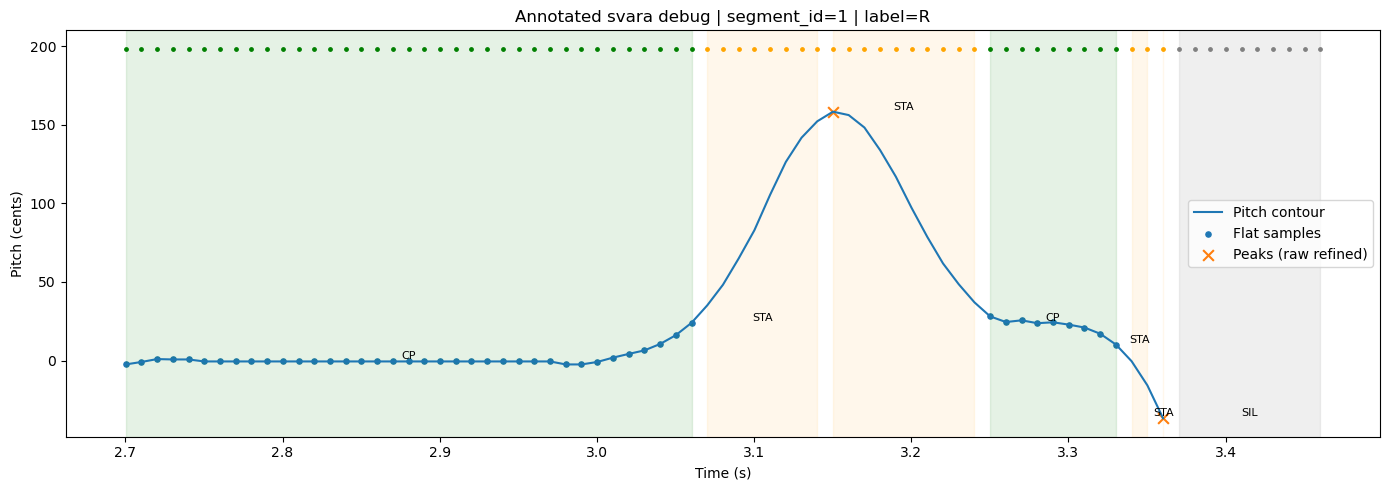

In [11]:
segment_id = 1

df_svara, df_debug, df_segments, segments, local_peak_map = (
    debug_one_annotated_svara_structural_segmentation(
        df_pitch=df_pitch,
        df_svaras=df_svaras,
        peak_row_map=peak_row_map,
        segment_id=segment_id,
        tau_init_sil=0.30,
    )
)

plot_one_annotated_svara_structural_debug(
    df_debug=df_debug,
    df_segments=df_segments,
    local_peak_map=local_peak_map,
)

In [12]:
df_peaks.filter(pl.col("distance_v_cents").abs() > 100).select([
    "time_savgol",
    "time_raw",
    "value_savgol_cents",
    "value_raw_cents",
    "distance_h_sec",
    "distance_v_cents",
]).sort("distance_v_cents")

time_savgol,time_raw,value_savgol_cents,value_raw_cents,distance_h_sec,distance_v_cents
f64,f64,f64,f64,f64,f64
414.476471,414.466461,660.324463,301.269539,-0.01001,-359.054924
165.11055,165.130554,995.049988,645.526916,0.020004,-349.523072
422.386993,422.396973,523.36853,201.500056,0.009979,-321.868474
418.35672,418.306732,730.508118,466.273767,-0.049988,-264.234351
275.4776,275.437592,672.678284,421.635425,-0.040009,-251.042858
…,…,…,…,…,…
410.716248,410.766235,730.761963,965.8919,0.049988,235.129937
340.331726,340.311737,639.223938,922.90733,-0.019989,283.683392
415.846558,415.876556,1032.225952,1386.76606,0.029999,354.540108


In [13]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from src.features.structural_embedding import structural_embedding_one_recording

recording_id = "srs_v1_svd_sav"
tonic_hz = S.SARASUDA_TONICS[recording_id]  # posa aquí la bona

df_emb = structural_embedding_one_recording(
    recording_id=recording_id,
    tonic_hz=tonic_hz,
    max_segments=12,
    tau_init_sil=0.30,
)
df_emb.head()

Structural embeddings saved: data/interim/srs_v1_svd_sav/features/srs_v1_svd_sav_svara_structural_embeddings.parquet


recording_id,segment_id,svara_label,t_start,t_end,duration_sec,n_rows,n_segments,embedding
str,i64,str,f64,f64,f64,i64,i64,list[f64]
"""srs_v1_svd_sav""",0,"""S""",2.046,2.696,0.65,65,4,"[0.640041, 1.0, … 0.0]"
"""srs_v1_svd_sav""",1,"""R""",2.696,3.461,0.765,77,7,"[0.760049, 1.0, … 0.0]"
"""srs_v1_svd_sav""",2,"""G""",3.461,4.274,0.813,81,10,"[0.800051, 0.0, … 0.0]"
"""srs_v1_svd_sav""",3,"""R""",4.274,4.662,0.388,39,4,"[0.380024, 0.0, … 0.0]"
"""srs_v1_svd_sav""",4,"""G""",4.662,5.05,0.388,38,3,"[0.370024, 0.0, … 0.0]"


In [14]:
SEG_DIM = 5  # [cp_onehot, sil_onehot, sta_onehot, dur_rel, cents]

def decode_embedding(embedding, max_segments=None):
    """
    Decode one embedding vector into:
    - total_duration
    - list of segment dicts
    """
    emb = np.asarray(embedding, dtype=float)
    total_duration = float(emb[0])

    rest = emb[1:]
    if len(rest) % SEG_DIM != 0:
        raise ValueError(f"Embedding length after total_duration is not divisible by {SEG_DIM}")

    n_slots = len(rest) // SEG_DIM
    if max_segments is None:
        max_segments = n_slots

    segments = []
    for i in range(min(n_slots, max_segments)):
        block = rest[i * SEG_DIM:(i + 1) * SEG_DIM]
        cp, sil, sta, dur_rel, cents = block

        # padding block = all zeros
        if np.allclose(block, 0.0):
            continue

        if cp == 1.0:
            typ = "CP"
        elif sil == 1.0:
            typ = "SIL"
        elif sta == 1.0:
            typ = "STA"
        else:
            typ = "UNK"

        segments.append({
            "slot": i,
            "type": typ,
            "cp": cp,
            "sil": sil,
            "sta": sta,
            "dur_rel": float(dur_rel),
            "cents": float(cents),
        })

    return total_duration, segments


def explode_embeddings(df_emb: pl.DataFrame) -> pl.DataFrame:
    """
    Turn one-row-per-svara embeddings into one-row-per-structural-segment.
    """
    rows = []

    for row in df_emb.iter_rows(named=True):
        total_duration, segments = decode_embedding(row["embedding"])

        for seg in segments:
            rows.append({
                "recording_id": row["recording_id"],
                "segment_id": row["segment_id"],     # annotated svara index
                "svara_label": row["svara_label"],
                "svara_duration_sec": row["duration_sec"],
                "n_segments": row["n_segments"],
                "embedding_total_duration": total_duration,
                **seg,
            })

    return pl.DataFrame(rows)

In [15]:
df_seg = explode_embeddings(df_emb)
df_seg.head()

recording_id,segment_id,svara_label,svara_duration_sec,n_segments,embedding_total_duration,slot,type,cp,sil,sta,dur_rel,cents
str,i64,str,f64,i64,f64,i64,str,f64,f64,f64,f64,f64
"""srs_v1_svd_sav""",0,"""S""",0.65,4,0.640041,0,"""CP""",1.0,0.0,0.0,0.734375,21.932497
"""srs_v1_svd_sav""",0,"""S""",0.65,4,0.640041,1,"""STA""",0.0,0.0,1.0,0.09375,22.558434
"""srs_v1_svd_sav""",0,"""S""",0.65,4,0.640041,2,"""STA""",0.0,0.0,1.0,0.109375,-90.865089
"""srs_v1_svd_sav""",0,"""S""",0.65,4,0.640041,3,"""CP""",1.0,0.0,0.0,0.015625,-9.914984
"""srs_v1_svd_sav""",1,"""R""",0.765,7,0.760049,0,"""CP""",1.0,0.0,0.0,0.473684,-0.577029


In [17]:
df_onehot_means = (
    df_seg
    .group_by("svara_label")
    .agg([
        pl.mean("cp").alias("mean_cp"),
        pl.mean("sil").alias("mean_sil"),
        pl.mean("sta").alias("mean_sta"),
        pl.mean("dur_rel").alias("mean_dur_rel"),
        pl.mean("cents").alias("mean_cents"),
        pl.len().alias("n_structural_segments"),
    ])
    .sort("svara_label")
)

df_onehot_means

svara_label,mean_cp,mean_sil,mean_sta,mean_dur_rel,mean_cents,n_structural_segments
str,f64,f64,f64,f64,f64,u32
"""D""",0.241042,0.04886,0.710098,0.187149,NaN,614
"""G""",0.227979,0.025907,0.746114,0.191278,575.215301,193
"""M""",0.144231,0.038462,0.817308,0.216772,NaN,312
"""N""",0.299065,0.018692,0.682243,0.212135,937.245164,214
"""P""",0.277929,0.073569,0.648501,0.252071,629.67304,367
"""R""",0.2,0.053763,0.746237,0.187828,NaN,465
"""S""",0.358885,0.083624,0.557491,0.272767,NaN,287


In [18]:
df_onehot_totals = (
    df_seg
    .group_by("svara_label")
    .agg([
        pl.sum("cp").alias("total_cp"),
        pl.sum("sil").alias("total_sil"),
        pl.sum("sta").alias("total_sta"),
        pl.len().alias("total_structural_segments"),
    ])
    .sort("svara_label")
)

df_onehot_totals

svara_label,total_cp,total_sil,total_sta,total_structural_segments
str,f64,f64,f64,u32
"""D""",148.0,30.0,436.0,614
"""G""",44.0,5.0,144.0,193
"""M""",45.0,12.0,255.0,312
"""N""",64.0,4.0,146.0,214
"""P""",102.0,27.0,238.0,367
"""R""",93.0,25.0,347.0,465
"""S""",103.0,24.0,160.0,287


In [19]:
df_mean_segments_per_svara = (
    df_emb
    .group_by("svara_label")
    .agg([
        pl.mean("n_segments").alias("mean_n_segments"),
        pl.std("n_segments").alias("std_n_segments"),
        pl.len().alias("n_annotated_svaras"),
        pl.mean("duration_sec").alias("mean_svara_duration_sec"),
    ])
    .sort("svara_label")
)

df_mean_segments_per_svara

svara_label,mean_n_segments,std_n_segments,n_annotated_svaras,mean_svara_duration_sec
str,f64,f64,u32,f64
"""D""",4.874016,2.260749,127,0.427535
"""G""",4.707317,1.453339,41,0.379732
"""M""",4.216216,1.528454,74,0.386838
"""N""",4.28,1.385641,50,0.36482
"""P""",3.707071,1.472555,99,0.43103
"""R""",4.84375,1.969922,96,0.452
"""S""",3.457831,1.508522,83,0.485337


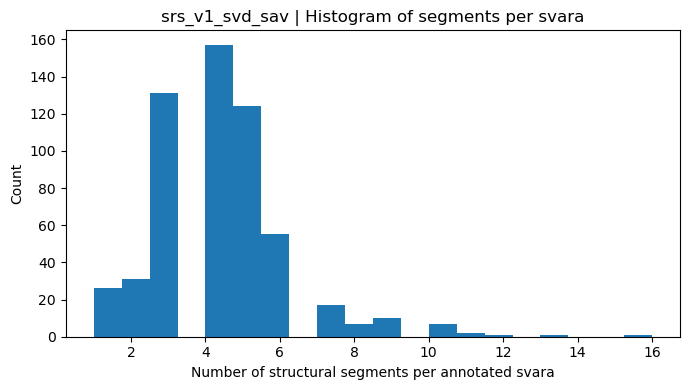

In [20]:
plt.figure(figsize=(7, 4))
plt.hist(df_emb["n_segments"].to_numpy(), bins=20)
plt.xlabel("Number of structural segments per annotated svara")
plt.ylabel("Count")
plt.title(f"{recording_id} | Histogram of segments per svara")
plt.tight_layout()
plt.show()

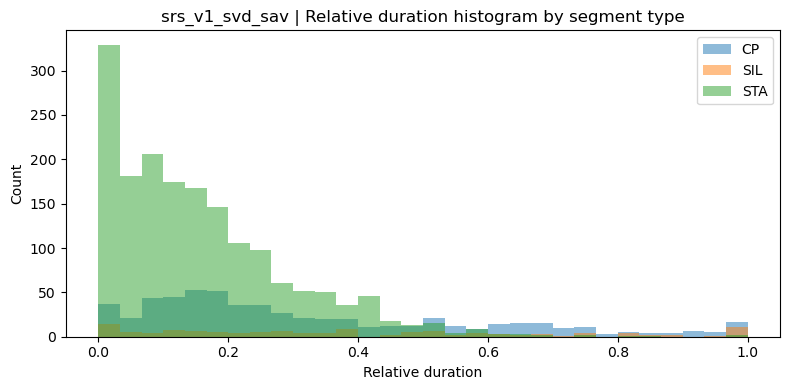

In [21]:
plt.figure(figsize=(8, 4))

for typ in ["CP", "SIL", "STA"]:
    vals = (
        df_seg
        .filter(pl.col("type") == typ)
        .get_column("dur_rel")
        .to_numpy()
    )
    if len(vals) > 0:
        plt.hist(vals, bins=30, alpha=0.5, label=typ)

plt.xlabel("Relative duration")
plt.ylabel("Count")
plt.title(f"{recording_id} | Relative duration histogram by segment type")
plt.legend()
plt.tight_layout()
plt.show()

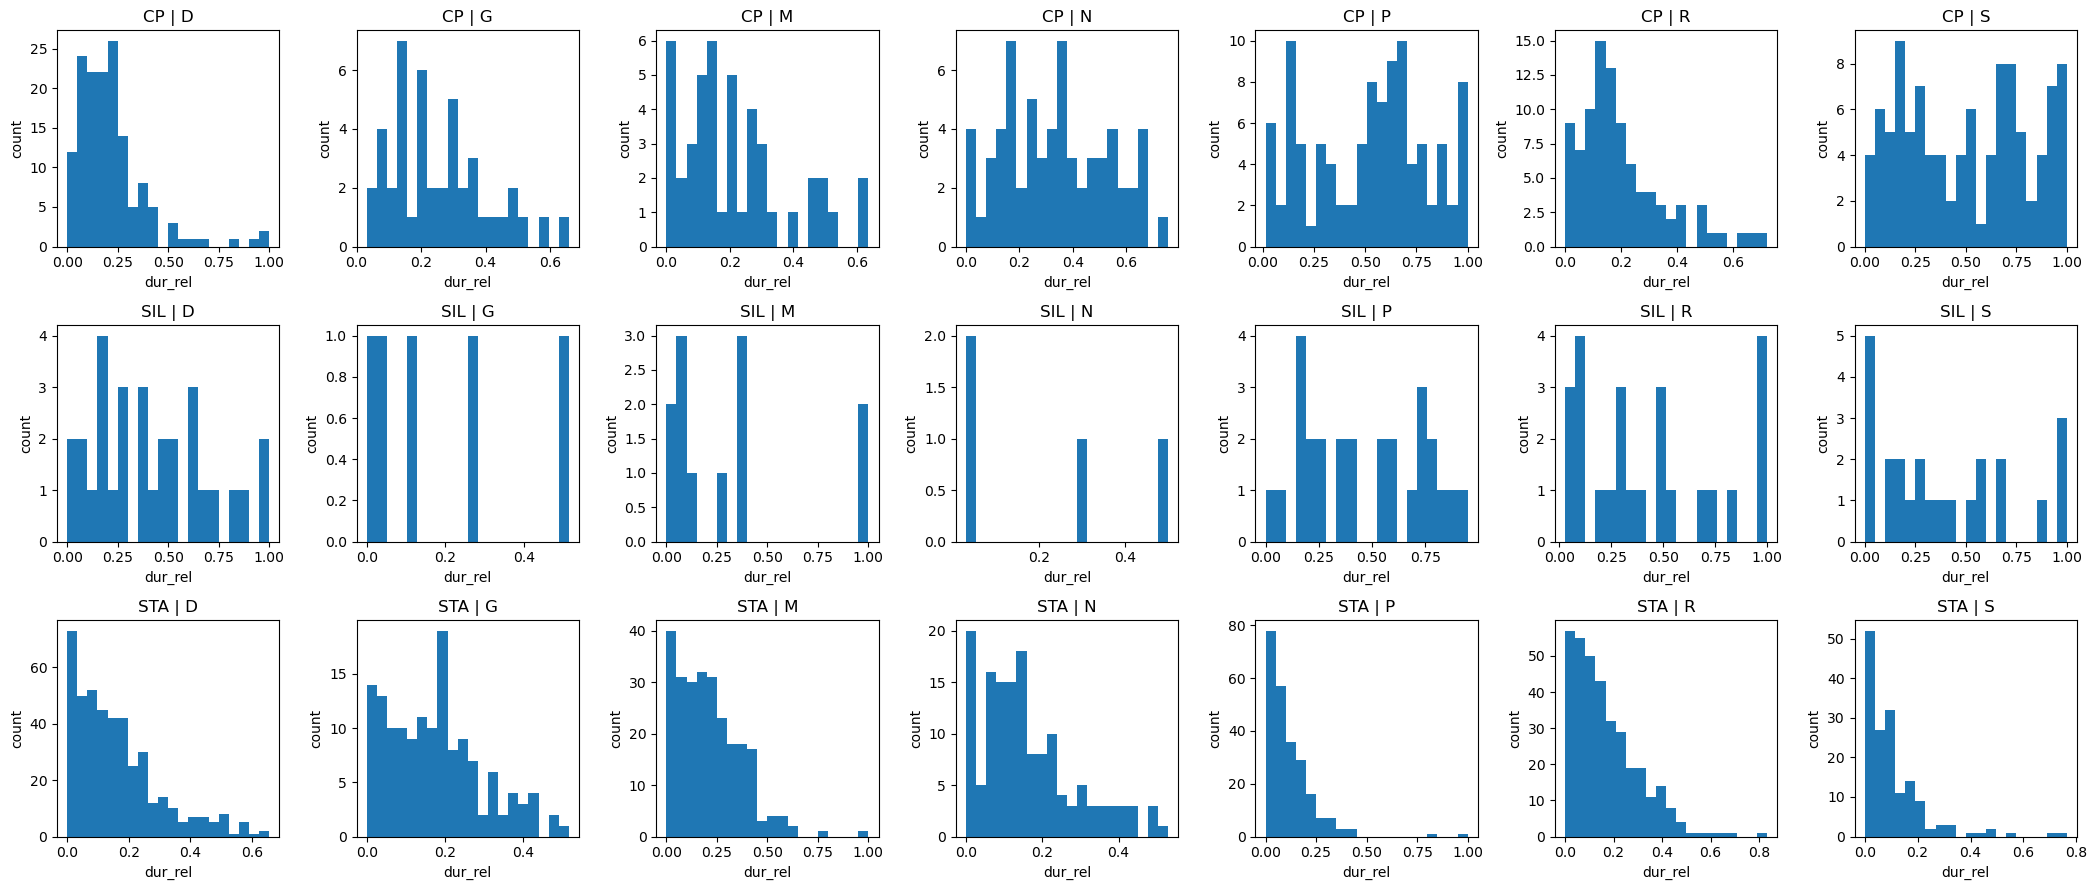

In [22]:
svara_labels = sorted(df_seg["svara_label"].unique().to_list())
types = ["CP", "SIL", "STA"]

fig, axes = plt.subplots(
    nrows=len(types),
    ncols=len(svara_labels),
    figsize=(3 * len(svara_labels), 3 * len(types)),
    squeeze=False
)

for i, typ in enumerate(types):
    for j, svara in enumerate(svara_labels):
        ax = axes[i, j]

        vals = (
            df_seg
            .filter(
                (pl.col("type") == typ) &
                (pl.col("svara_label") == svara)
            )
            .get_column("dur_rel")
            .to_numpy()
        )

        if len(vals) > 0:
            ax.hist(vals, bins=20)

        ax.set_title(f"{typ} | {svara}")
        ax.set_xlabel("dur_rel")
        ax.set_ylabel("count")

plt.tight_layout()
plt.show()

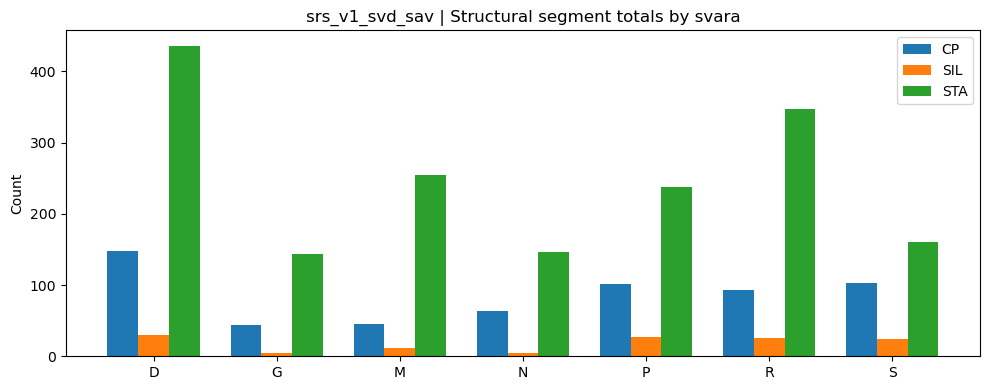

In [23]:
df_plot = df_onehot_totals.sort("svara_label")
labels = df_plot["svara_label"].to_list()
cp_vals = df_plot["total_cp"].to_numpy()
sil_vals = df_plot["total_sil"].to_numpy()
sta_vals = df_plot["total_sta"].to_numpy()

x = np.arange(len(labels))
w = 0.25

plt.figure(figsize=(10, 4))
plt.bar(x - w, cp_vals, width=w, label="CP")
plt.bar(x,     sil_vals, width=w, label="SIL")
plt.bar(x + w, sta_vals, width=w, label="STA")
plt.xticks(x, labels)
plt.ylabel("Count")
plt.title(f"{recording_id} | Structural segment totals by svara")
plt.legend()
plt.tight_layout()
plt.show()

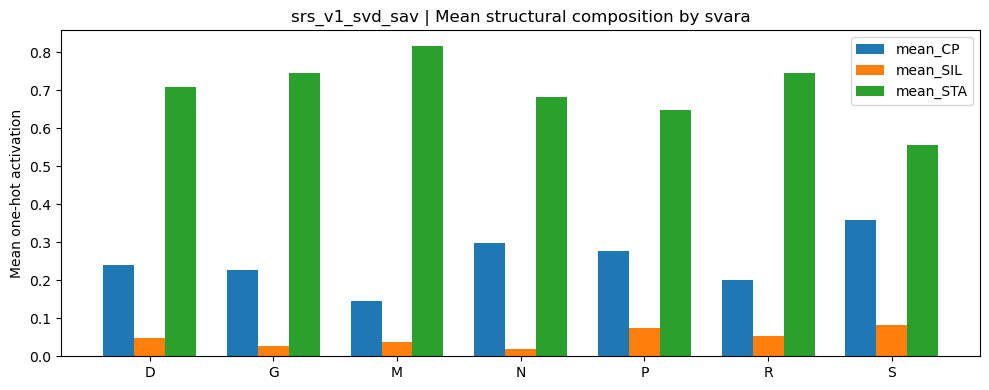

In [24]:
df_plot = df_onehot_means.sort("svara_label")
labels = df_plot["svara_label"].to_list()
cp_vals = df_plot["mean_cp"].to_numpy()
sil_vals = df_plot["mean_sil"].to_numpy()
sta_vals = df_plot["mean_sta"].to_numpy()

x = np.arange(len(labels))
w = 0.25

plt.figure(figsize=(10, 4))
plt.bar(x - w, cp_vals, width=w, label="mean_CP")
plt.bar(x,     sil_vals, width=w, label="mean_SIL")
plt.bar(x + w, sta_vals, width=w, label="mean_STA")
plt.xticks(x, labels)
plt.ylabel("Mean one-hot activation")
plt.title(f"{recording_id} | Mean structural composition by svara")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
df_summary = (
    df_onehot_means
    .join(df_onehot_totals, on="svara_label", how="inner")
    .join(df_mean_segments_per_svara, on="svara_label", how="inner")
    .sort("svara_label")
)

df_summary

svara_label,mean_cp,mean_sil,mean_sta,mean_dur_rel,mean_cents,n_structural_segments,total_cp,total_sil,total_sta,total_structural_segments,mean_n_segments,std_n_segments,n_annotated_svaras,mean_svara_duration_sec
str,f64,f64,f64,f64,f64,u32,f64,f64,f64,u32,f64,f64,u32,f64
"""D""",0.241042,0.04886,0.710098,0.187149,NaN,614,148.0,30.0,436.0,614,4.874016,2.260749,127,0.427535
"""G""",0.227979,0.025907,0.746114,0.191278,575.215301,193,44.0,5.0,144.0,193,4.707317,1.453339,41,0.379732
"""M""",0.144231,0.038462,0.817308,0.216772,NaN,312,45.0,12.0,255.0,312,4.216216,1.528454,74,0.386838
"""N""",0.299065,0.018692,0.682243,0.212135,937.245164,214,64.0,4.0,146.0,214,4.28,1.385641,50,0.36482
"""P""",0.277929,0.073569,0.648501,0.252071,629.67304,367,102.0,27.0,238.0,367,3.707071,1.472555,99,0.43103
"""R""",0.2,0.053763,0.746237,0.187828,NaN,465,93.0,25.0,347.0,465,4.84375,1.969922,96,0.452
"""S""",0.358885,0.083624,0.557491,0.272767,NaN,287,103.0,24.0,160.0,287,3.457831,1.508522,83,0.485337


In [26]:
import numpy as np
import polars as pl
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# ---------------------------------------
# Decode embedding → sequence of labels
# ---------------------------------------
def decode_embedding(embedding, max_segments=12):
    segs = []
    offset = 1  # skip total_duration

    for i in range(max_segments):
        base = offset + i * 5
        onehot = embedding[base:base+3]

        if sum(onehot) == 0:
            continue  # padding

        if onehot[0] == 1:
            segs.append("CP")
        elif onehot[1] == 1:
            segs.append("SIL")
        elif onehot[2] == 1:
            segs.append("STA")

    return segs


# ---------------------------------------
# Build sequences per svara
# ---------------------------------------
def extract_sequences(df_emb):
    sequences = []
    labels = []

    for row in df_emb.iter_rows(named=True):
        seq = decode_embedding(row["embedding"])
        if len(seq) == 0:
            continue

        sequences.append(seq)
        labels.append(row["svara_label"])

    return sequences, labels


# ---------------------------------------
# GLOBAL DISTRIBUTION
# ---------------------------------------
def global_type_distribution(sequences):
    counter = Counter()

    for seq in sequences:
        counter.update(seq)

    total = sum(counter.values())
    dist = {k: v / total for k, v in counter.items()}

    return counter, dist


# ---------------------------------------
# FIRST SEGMENT ANALYSIS
# ---------------------------------------
def first_segment_distribution(sequences):
    counter = Counter()

    for seq in sequences:
        counter[seq[0]] += 1

    total = sum(counter.values())
    dist = {k: v / total for k, v in counter.items()}

    return counter, dist


# ---------------------------------------
# TRANSITIONS (bigrams)
# ---------------------------------------
def transition_counts(sequences):
    counter = Counter()

    for seq in sequences:
        for i in range(len(seq) - 1):
            pair = (seq[i], seq[i+1])
            counter[pair] += 1

    return counter


# ---------------------------------------
# MOST COMMON CHAINS
# ---------------------------------------
def most_common_sequences(sequences, k=10):
    counter = Counter(tuple(seq) for seq in sequences)
    return counter.most_common(k)


# ---------------------------------------
# SEGMENT COUNT PER SVARA
# ---------------------------------------
def segment_length_stats(sequences):
    lengths = [len(seq) for seq in sequences]
    return np.mean(lengths), np.std(lengths), lengths


# ---------------------------------------
# PER-SVARA ANALYSIS
# ---------------------------------------
def per_svara_analysis(sequences, labels):
    data = defaultdict(list)

    for seq, lab in zip(sequences, labels):
        data[lab].append(seq)

    out = {}

    for svara, seqs in data.items():
        counter, dist = global_type_distribution(seqs)
        first_counter, first_dist = first_segment_distribution(seqs)
        mean_len, std_len, _ = segment_length_stats(seqs)

        out[svara] = {
            "type_dist": dist,
            "first_dist": first_dist,
            "mean_len": mean_len,
            "n": len(seqs),
        }

    return out


# ---------------------------------------
# RUN ANALYSIS
# ---------------------------------------
sequences, labels = extract_sequences(df_emb)

# GLOBAL
counter, dist = global_type_distribution(sequences)
print("\nGLOBAL TYPE DISTRIBUTION")
print(counter)
print(dist)

# FIRST SEGMENT
first_counter, first_dist = first_segment_distribution(sequences)
print("\nFIRST SEGMENT DISTRIBUTION")
print(first_counter)
print(first_dist)

# TRANSITIONS
trans = transition_counts(sequences)
print("\nTOP TRANSITIONS")
print(trans.most_common(10))

# CHAINS
print("\nMOST COMMON FULL SEQUENCES")
for seq, c in most_common_sequences(sequences, k=10):
    print(c, seq)

# LENGTHS
mean_len, std_len, lengths = segment_length_stats(sequences)
print("\nSEGMENT COUNT PER SVARA")
print("mean:", mean_len, "std:", std_len)

# PER SVARA
per_svara = per_svara_analysis(sequences, labels)

print("\nPER-SVARA SUMMARY")
for svara, d in per_svara.items():
    print(svara, d)


GLOBAL TYPE DISTRIBUTION
Counter({'STA': 1726, 'CP': 599, 'SIL': 127})
{'CP': 0.24429037520391517, 'STA': 0.7039151712887439, 'SIL': 0.051794453507340944}

FIRST SEGMENT DISTRIBUTION
Counter({'STA': 362, 'CP': 153, 'SIL': 55})
{'CP': 0.26842105263157895, 'SIL': 0.09649122807017543, 'STA': 0.6350877192982456}

TOP TRANSITIONS
[(('STA', 'STA'), 859), (('STA', 'CP'), 446), (('CP', 'STA'), 436), (('SIL', 'STA'), 69), (('STA', 'SIL'), 53), (('CP', 'SIL'), 19)]

MOST COMMON FULL SEQUENCES
34 ('STA', 'STA', 'STA')
31 ('STA', 'CP', 'STA', 'STA')
29 ('CP', 'STA', 'STA')
29 ('STA', 'STA', 'STA', 'STA')
27 ('STA', 'STA', 'CP', 'STA', 'STA')
23 ('CP', 'STA', 'STA', 'STA')
21 ('STA', 'CP', 'STA')
21 ('STA', 'CP')
17 ('STA', 'STA', 'STA', 'STA', 'STA')
14 ('STA', 'STA', 'CP')

SEGMENT COUNT PER SVARA
mean: 4.301754385964912 std: 1.795754371910354

PER-SVARA SUMMARY
S {'type_dist': {'CP': 0.3588850174216028, 'STA': 0.5574912891986062, 'SIL': 0.08362369337979095}, 'first_dist': {'CP': 0.3012048192771

In [27]:
import numpy as np
import polars as pl
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# ---------------------------------------
# Decode embedding
# ---------------------------------------
def decode_embedding(embedding, max_segments=12):
    segs = []
    offset = 1

    for i in range(max_segments):
        base = offset + i * 5
        onehot = embedding[base:base+3]

        if sum(onehot) == 0:
            continue

        if onehot[0] == 1:
            segs.append("CP")
        elif onehot[1] == 1:
            segs.append("SIL")
        elif onehot[2] == 1:
            segs.append("STA")

    return segs


# ---------------------------------------
# Build per-svara sequences
# ---------------------------------------
def group_by_svara(df_emb):
    data = defaultdict(list)

    for row in df_emb.iter_rows(named=True):
        seq = decode_embedding(row["embedding"])
        if len(seq) == 0:
            continue

        svara = row["svara_label"]
        data[svara].append(seq)

    return data


# ---------------------------------------
# ANALYSIS PER SVARA
# ---------------------------------------
def analyze_svara(seqs):
    # type distribution
    type_counter = Counter()
    for s in seqs:
        type_counter.update(s)

    total = sum(type_counter.values())
    type_dist = {k: v / total for k, v in type_counter.items()}

    # first segment
    first_counter = Counter(s[0] for s in seqs)
    total_first = sum(first_counter.values())
    first_dist = {k: v / total_first for k, v in first_counter.items()}

    # transitions
    trans_counter = Counter()
    for s in seqs:
        for i in range(len(s) - 1):
            trans_counter[(s[i], s[i+1])] += 1

    # lengths
    lengths = [len(s) for s in seqs]
    mean_len = np.mean(lengths)
    std_len = np.std(lengths)

    # common sequences
    seq_counter = Counter(tuple(s) for s in seqs)
    common_seq = seq_counter.most_common(5)

    return {
        "type_dist": type_dist,
        "first_dist": first_dist,
        "transitions": trans_counter,
        "mean_len": mean_len,
        "std_len": std_len,
        "common_seq": common_seq,
        "n": len(seqs)
    }


# ---------------------------------------
# RUN FULL ANALYSIS
# ---------------------------------------
data = group_by_svara(df_emb)

results = {}
for svara, seqs in data.items():
    results[svara] = analyze_svara(seqs)

# ---------------------------------------
# PRINT CLEAN SUMMARY
# ---------------------------------------
for svara, r in results.items():
    print("\n==============================")
    print(f"SVARA: {svara}  (n={r['n']})")

    print("\nType distribution:")
    print(r["type_dist"])

    print("\nStart distribution:")
    print(r["first_dist"])

    print("\nMean segments:", r["mean_len"], "±", r["std_len"])

    print("\nTop transitions:")
    print(r["transitions"].most_common(5))

    print("\nTop sequences:")
    for seq, c in r["common_seq"]:
        print(c, seq)


SVARA: S  (n=83)

Type distribution:
{'CP': 0.3588850174216028, 'STA': 0.5574912891986062, 'SIL': 0.08362369337979095}

Start distribution:
{'CP': 0.30120481927710846, 'SIL': 0.1566265060240964, 'STA': 0.5421686746987951}

Mean segments: 3.4578313253012047 ± 1.4994071504678599

Top transitions:
[(('STA', 'CP'), 78), (('CP', 'STA'), 55), (('STA', 'STA'), 44), (('SIL', 'STA'), 16), (('CP', 'SIL'), 6)]

Top sequences:
10 ('STA', 'CP')
7 ('STA', 'CP', 'STA')
7 ('CP', 'STA', 'CP')
6 ('CP',)
5 ('STA', 'STA', 'CP', 'STA', 'STA')

SVARA: R  (n=96)

Type distribution:
{'CP': 0.2, 'STA': 0.7462365591397849, 'SIL': 0.053763440860215055}

Start distribution:
{'CP': 0.19791666666666666, 'STA': 0.6875, 'SIL': 0.11458333333333333}

Mean segments: 4.84375 ± 1.9596349840807938

Top transitions:
[(('STA', 'STA'), 198), (('STA', 'CP'), 74), (('CP', 'STA'), 72), (('STA', 'SIL'), 12), (('SIL', 'STA'), 11)]

Top sequences:
8 ('STA', 'STA', 'STA', 'STA')
7 ('STA', 'STA', 'CP', 'STA', 'STA')
5 ('STA', 'CP', 

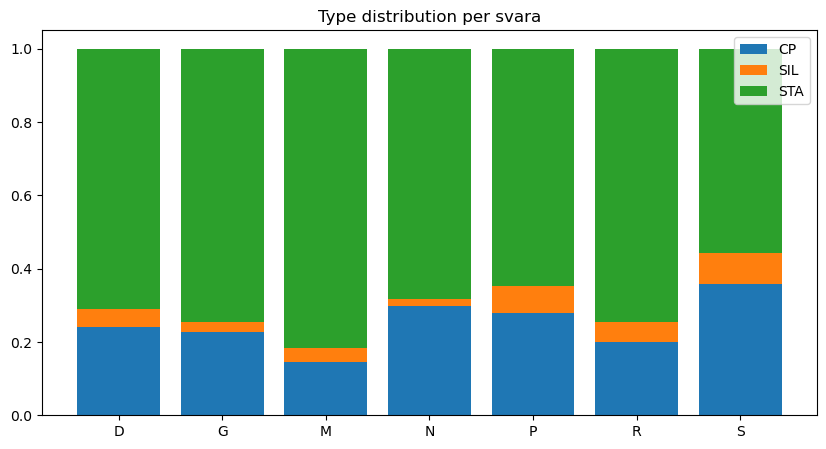

In [28]:
labels = sorted(results.keys())

cp = [results[s]["type_dist"].get("CP", 0) for s in labels]
sil = [results[s]["type_dist"].get("SIL", 0) for s in labels]
sta = [results[s]["type_dist"].get("STA", 0) for s in labels]

x = np.arange(len(labels))

plt.figure(figsize=(10,5))
plt.bar(x, cp, label="CP")
plt.bar(x, sil, bottom=cp, label="SIL")
plt.bar(x, sta, bottom=np.array(cp)+np.array(sil), label="STA")

plt.xticks(x, labels)
plt.title("Type distribution per svara")
plt.legend()
plt.show()

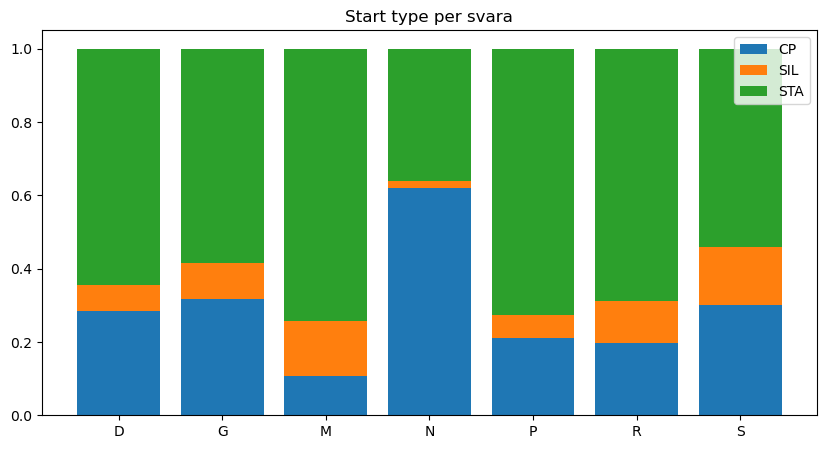

In [29]:
cp = [results[s]["first_dist"].get("CP", 0) for s in labels]
sil = [results[s]["first_dist"].get("SIL", 0) for s in labels]
sta = [results[s]["first_dist"].get("STA", 0) for s in labels]

plt.figure(figsize=(10,5))
plt.bar(x, cp, label="CP")
plt.bar(x, sil, bottom=cp, label="SIL")
plt.bar(x, sta, bottom=np.array(cp)+np.array(sil), label="STA")

plt.xticks(x, labels)
plt.title("Start type per svara")
plt.legend()
plt.show()

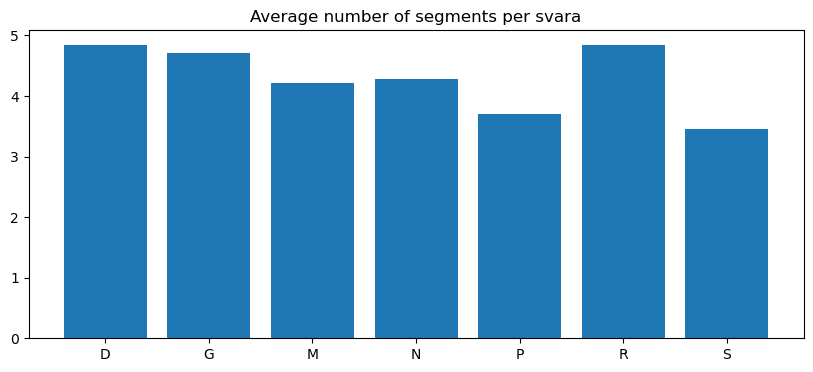

In [30]:
means = [results[s]["mean_len"] for s in labels]

plt.figure(figsize=(10,4))
plt.bar(labels, means)
plt.title("Average number of segments per svara")
plt.show()

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter, defaultdict

In [32]:
def decode_embedding(embedding, max_segments=12):
    segs = []
    offset = 1
    for i in range(max_segments):
        base = offset + i * 5
        onehot = embedding[base:base+3]
        if sum(onehot) == 0:
            continue
        if onehot[0] == 1:
            segs.append("CP")
        elif onehot[1] == 1:
            segs.append("SIL")
        elif onehot[2] == 1:
            segs.append("STA")
    return segs

def group_by_svara(df_emb):
    data = defaultdict(list)
    for row in df_emb.iter_rows(named=True):
        seq = decode_embedding(row["embedding"])
        if len(seq) == 0:
            continue
        data[row["svara_label"]].append(seq)
    return data

data = group_by_svara(df_emb)

In [33]:
def transition_counter_for_sequences(seqs):
    counter = Counter()
    for s in seqs:
        for i in range(len(s) - 1):
            counter[(s[i], s[i+1])] += 1
    return counter

In [34]:
def plot_transition_graph_for_svara(
    svara_label,
    seqs,
    normalize=True,
    min_weight=0.0,
    title=None,
):
    """
    Plot a directed transition graph for one svara.

    Nodes: SIL, CP, STA
    Edges: observed transitions
    Edge width: frequency
    Edge labels: count or probability
    """

    counter = transition_counter_for_sequences(seqs)
    total_out = defaultdict(int)
    for (a, b), c in counter.items():
        total_out[a] += c

    G = nx.DiGraph()

    nodes = ["SIL", "CP", "STA"]
    for n in nodes:
        G.add_node(n)

    edge_labels = {}
    edge_widths = []

    for (a, b), c in counter.items():
        w = c / total_out[a] if normalize and total_out[a] > 0 else c
        if w < min_weight:
            continue
        G.add_edge(a, b, weight=w, count=c)
        edge_labels[(a, b)] = f"{w:.2f}" if normalize else str(c)

    # fixed layout for interpretability
    pos = {
        "SIL": (-1, 0),
        "CP":  (0, 1),
        "STA": (1, 0),
    }

    plt.figure(figsize=(6, 5))

    nx.draw_networkx_nodes(G, pos, node_size=2200)
    nx.draw_networkx_labels(G, pos, font_size=12)

    if G.number_of_edges() > 0:
        widths = []
        for a, b in G.edges():
            w = G[a][b]["weight"]
            widths.append(1 + 8 * w if normalize else 1 + 0.15 * G[a][b]["count"])

        nx.draw_networkx_edges(
            G,
            pos,
            width=widths,
            arrows=True,
            arrowsize=20,
            connectionstyle="arc3,rad=0.15",
        )

        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels=edge_labels,
            font_size=10,
            label_pos=0.55,
        )

    plt.title(title or f"Transition graph | {svara_label}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

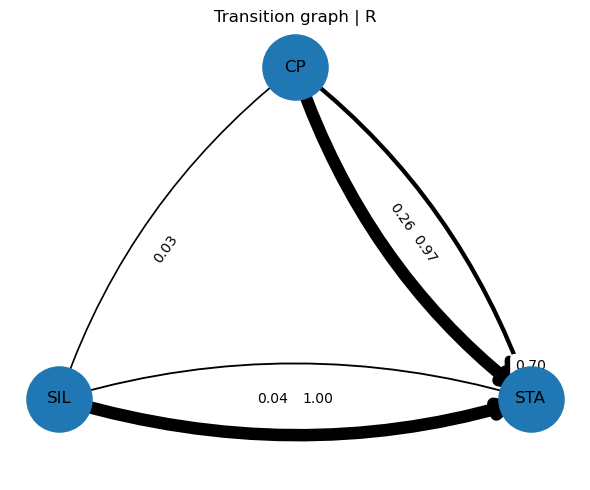

In [37]:
svara = "R"   # canvia-ho
plot_transition_graph_for_svara(
    svara_label=svara,
    seqs=data[svara],
    normalize=True,
    min_weight=0.0,
)

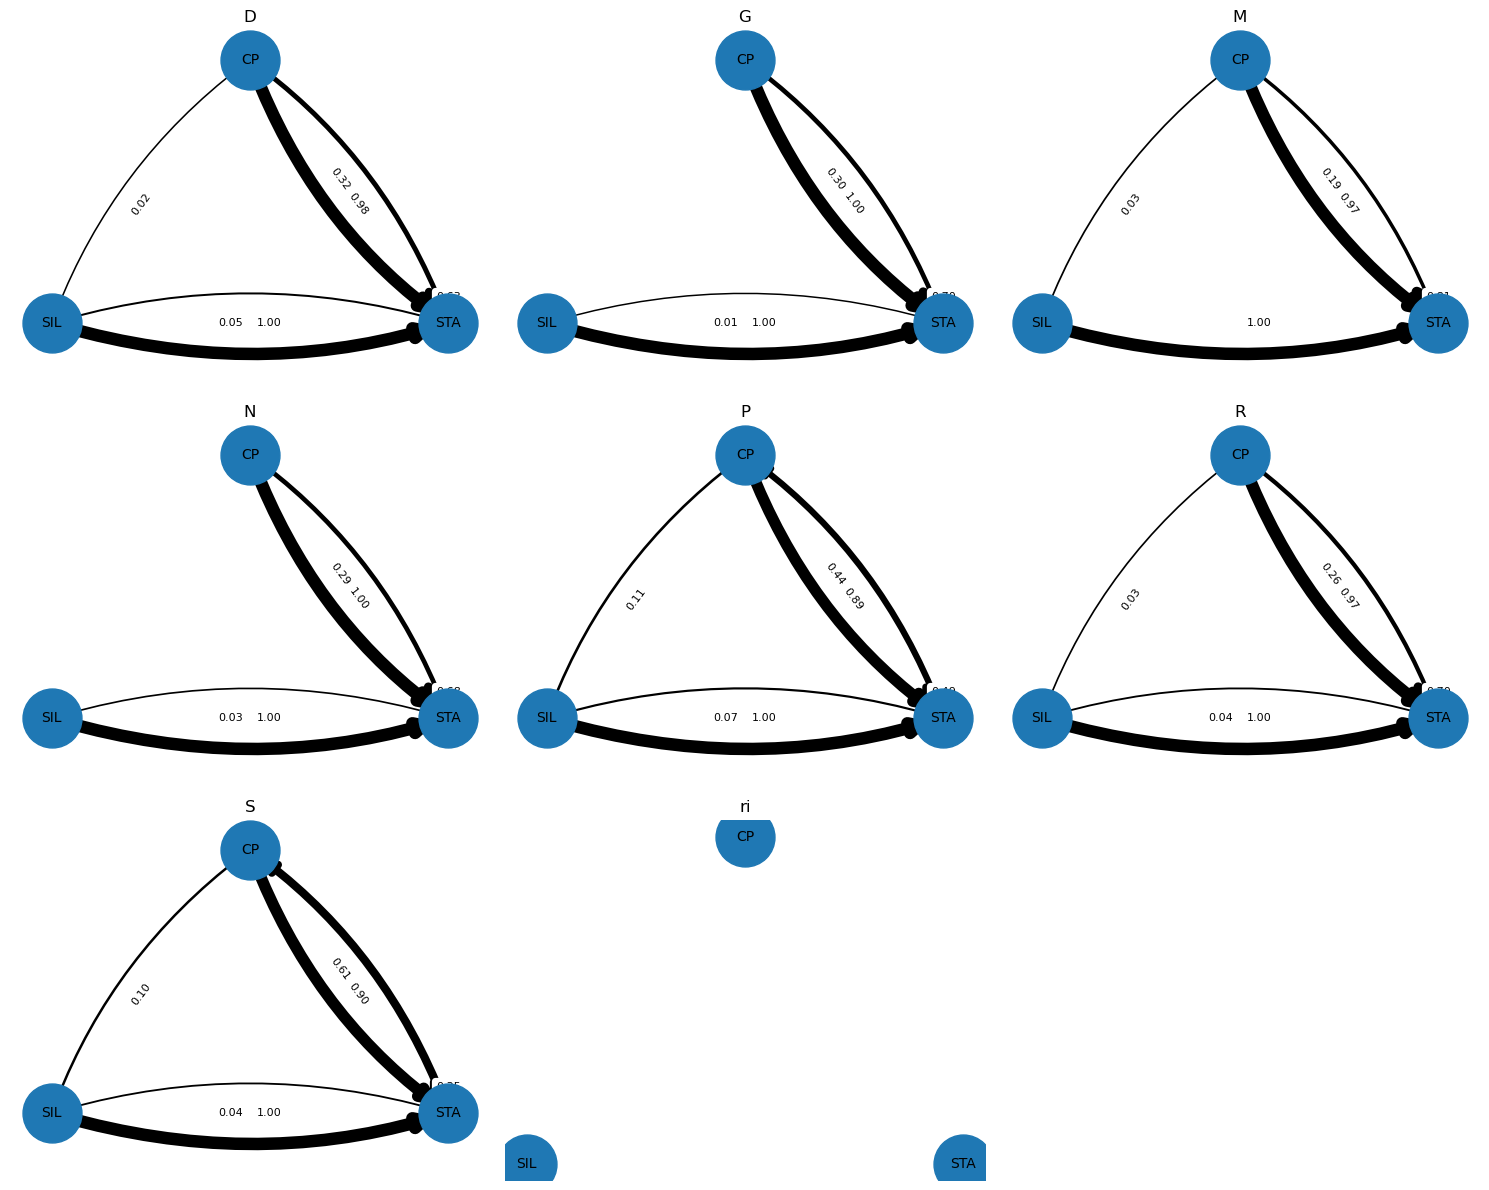

In [38]:
labels = sorted(data.keys())

fig, axes = plt.subplots(
    nrows=int(np.ceil(len(labels)/3)),
    ncols=3,
    figsize=(15, 4 * int(np.ceil(len(labels)/3)))
)
axes = np.array(axes).reshape(-1)

for ax, svara in zip(axes, labels):
    counter = transition_counter_for_sequences(data[svara])
    total_out = defaultdict(int)
    for (a, b), c in counter.items():
        total_out[a] += c

    G = nx.DiGraph()
    nodes = ["SIL", "CP", "STA"]
    for n in nodes:
        G.add_node(n)

    edge_labels = {}
    for (a, b), c in counter.items():
        w = c / total_out[a] if total_out[a] > 0 else 0.0
        G.add_edge(a, b, weight=w, count=c)
        edge_labels[(a, b)] = f"{w:.2f}"

    pos = {"SIL": (-1, 0), "CP": (0, 1), "STA": (1, 0)}

    plt.sca(ax)
    nx.draw_networkx_nodes(G, pos, node_size=1800, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)

    if G.number_of_edges() > 0:
        widths = [1 + 8 * G[a][b]["weight"] for a, b in G.edges()]
        nx.draw_networkx_edges(
            G, pos,
            width=widths,
            arrows=True,
            arrowsize=18,
            connectionstyle="arc3,rad=0.15",
            ax=ax
        )
        nx.draw_networkx_edge_labels(
            G, pos,
            edge_labels=edge_labels,
            font_size=8,
            label_pos=0.55,
            ax=ax
        )

    ax.set_title(svara)
    ax.axis("off")

for ax in axes[len(labels):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [39]:
def prefix_tree_edges(seqs):
    """
    Build weighted edges for a prefix tree:
    START -> CP -> STA -> ...
    """
    counter = Counter()
    for seq in seqs:
        path = ["START"] + seq
        for i in range(len(path) - 1):
            a = tuple(path[:i+1])
            b = tuple(path[:i+2])
            counter[(a, b)] += 1
    return counter

In [40]:
def plot_prefix_tree_for_svara(
    svara_label,
    seqs,
    min_count=2,
    title=None,
):
    """
    Plot a branching prefix graph for one svara.
    Nodes are prefixes like:
        START
        START-CP
        START-CP-STA
    """

    edge_counter = prefix_tree_edges(seqs)

    G = nx.DiGraph()

    for (a, b), c in edge_counter.items():
        if c < min_count:
            continue
        G.add_edge(a, b, count=c)

    if G.number_of_nodes() == 0:
        print(f"No edges above min_count={min_count} for {svara_label}")
        return

    # depth-based layout
    nodes_by_depth = defaultdict(list)
    for node in G.nodes():
        depth = len(node) - 1  # START has depth 0
        nodes_by_depth[depth].append(node)

    pos = {}
    for depth, nodes in nodes_by_depth.items():
        ys = np.linspace(0, 1, len(nodes)) if len(nodes) > 1 else [0.5]
        for y, node in zip(ys, nodes):
            pos[node] = (depth, 1 - y)

    plt.figure(figsize=(12, 6))

    nx.draw_networkx_nodes(G, pos, node_size=1200)
    labels = {n: "-".join(n) for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

    widths = [1 + 0.4 * G[a][b]["count"] for a, b in G.edges()]
    nx.draw_networkx_edges(G, pos, width=widths, arrows=True, arrowsize=16)

    edge_labels = {(a, b): str(G[a][b]["count"]) for a, b in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title or f"Prefix tree | {svara_label}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

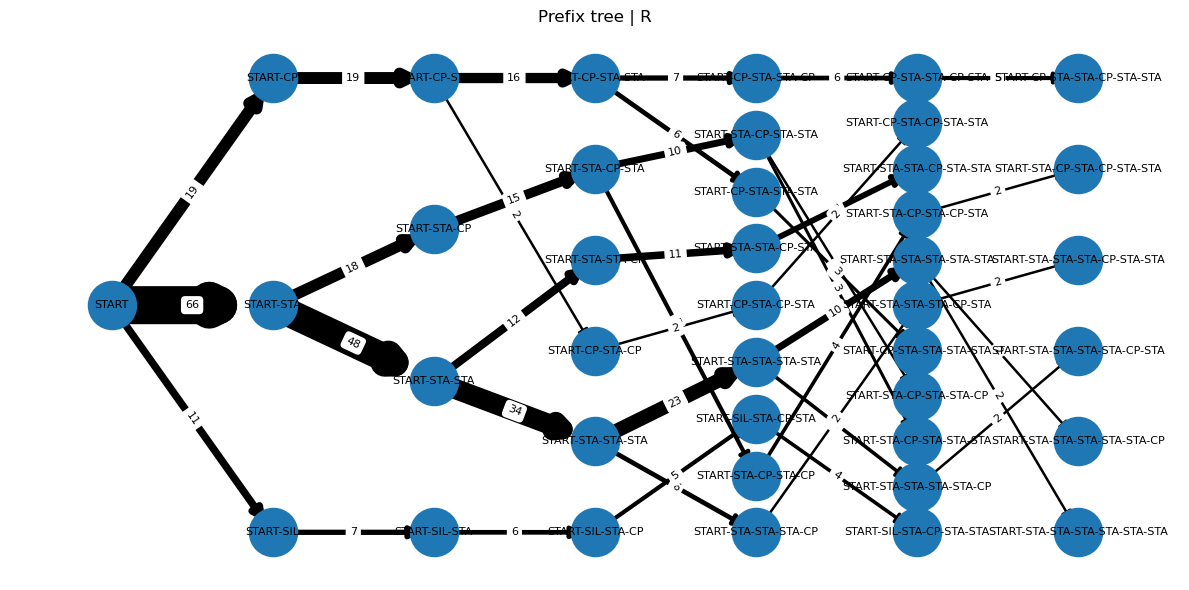

In [41]:
svara = "R"
plot_prefix_tree_for_svara(
    svara_label=svara,
    seqs=data[svara],
    min_count=2,
)